# Phase 1 - ML Models
fake news detection project

track B - using fake and real news dataset from kaggle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

RANDOM_STATE = 42
print('done')

done


## load the data
dataset has 2 files, Fake.csv and True.csv  
i need to combine them and add a label column

In [2]:
fake = pd.read_csv('data/raw/Fake.csv')
true = pd.read_csv('data/raw/True.csv')

fake['label'] = 'FAKE'
true['label'] = 'REAL'

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL


In [3]:
# check for missing values
print(df.isnull().sum())
print()
print(df.dtypes)

title      0
text       0
subject    0
date       0
label      0
dtype: int64

title      str
text       str
subject    str
date       str
label      str
dtype: object


In [6]:
# class balance
print(df['label'].value_counts())

label
FAKE    23481
REAL    21417
Name: count, dtype: int64


C:\Users\mmmal\AppData\Local\Temp\ipykernel_14360\754797659.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#e74c3c', '#2ecc71'])


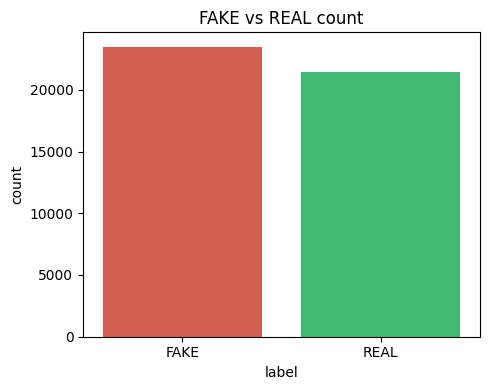

In [5]:
# plot class balance
plt.figure(figsize=(5, 4))
sns.countplot(x='label', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('FAKE vs REAL count')
plt.xlabel('label')
plt.ylabel('count')
plt.tight_layout()
plt.show()

## preprocessing
- combine title and text into one column
- convert label to 0/1
- clean the text (lowercase, remove numbers and punctuation)

In [8]:
# merge title + text
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# FAKE=0, REAL=1
df['label_num'] = df['label'].map({'FAKE': 0, 'REAL': 1})

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)   # remove urls
    text = re.sub(r'\d+', '', text)       # remove numbers
    text = re.sub(r'[^\w\s]', '', text)   # remove punctuation
    text = ' '.join(text.split())          # fix whitespace
    return text

df['content_clean'] = df['content'].apply(clean_text)

## split data + tfidf

split: 70% train / 15% val / 15% test  
i chose this because 70% is enough to train and 15% each gives enough samples to evaluate

In [11]:
X = df['content_clean']
y = df['label_num']

# first split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# then split remaining into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE, stratify=y_temp
)

print('train:', len(X_train))
print('val:  ', len(X_val))
print('test: ', len(X_test))

train: 31446
val:   6717
test:  6735


In [12]:
# vectorize - fit on train only!
tfidf = TfidfVectorizer(max_features=10000)

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)
X_test_vec  = tfidf.transform(X_test)

print(X_train_vec.shape)
print(X_val_vec.shape)

(31446, 10000)
(6717, 10000)


## train 3 models

In [13]:
# logistic regression
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_vec, y_train)
print('lr done')

lr done


In [14]:
# random forest
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train_vec, y_train)
print('rf done')

rf done


In [15]:
# naive bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
print('nb done')

nb done


## evaluate models
using accuracy, precision, recall and f1  
evaluate_model() function so i can reuse it for all models

In [16]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    return {
        'accuracy':  round(accuracy_score(y, preds), 4),
        'precision': round(precision_score(y, preds), 4),
        'recall':    round(recall_score(y, preds), 4),
        'f1':        round(f1_score(y, preds), 4)
    }

lr_scores = evaluate_model(lr, X_val_vec, y_val)
rf_scores = evaluate_model(rf, X_val_vec, y_val)
nb_scores = evaluate_model(nb, X_val_vec, y_val)

print('LR:', lr_scores)
print('RF:', rf_scores)
print('NB:', nb_scores)

LR: {'accuracy': 0.9875, 'precision': 0.9851, 'recall': 0.9888, 'f1': 0.9869}
RF: {'accuracy': 0.9961, 'precision': 0.9969, 'recall': 0.995, 'f1': 0.9959}
NB: {'accuracy': 0.9419, 'precision': 0.9351, 'recall': 0.9438, 'f1': 0.9394}


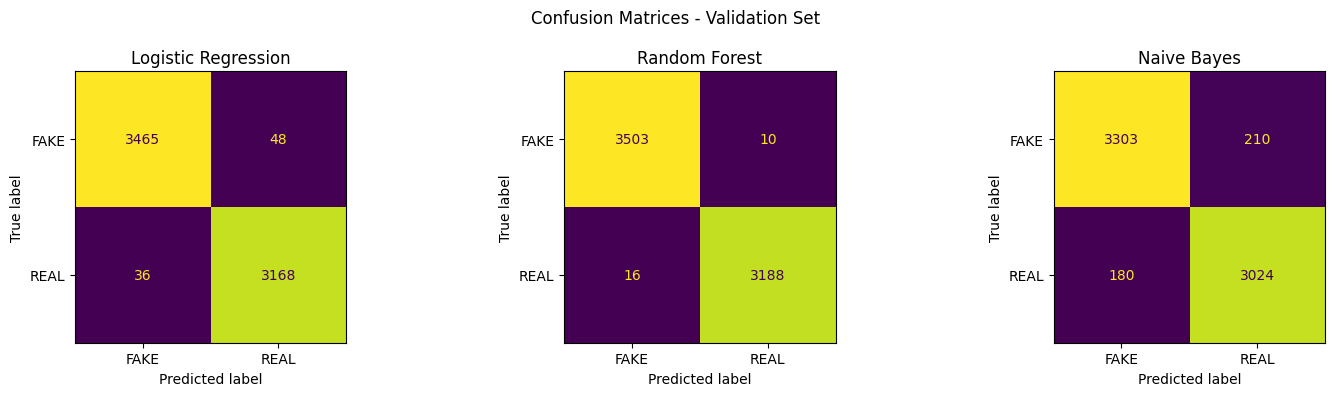

In [17]:
# confusion matrix for each model
models = [lr, rf, nb]
names  = ['Logistic Regression', 'Random Forest', 'Naive Bayes']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model, name in zip(axes, models, names):
    preds = model.predict(X_val_vec)
    cm = confusion_matrix(y_val, preds)
    ConfusionMatrixDisplay(cm, display_labels=['FAKE', 'REAL']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrices - Validation Set')
plt.tight_layout()
plt.show()

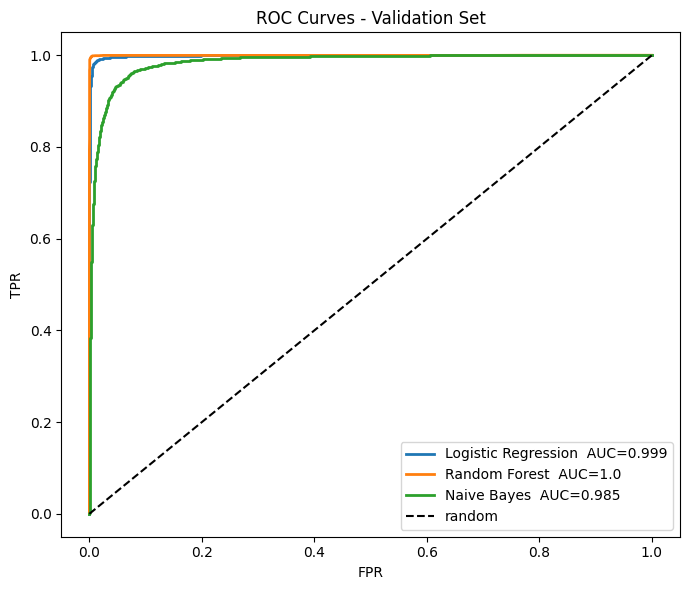

In [18]:
# roc curves for all models
def plot_roc(model, name, X, y):
    proba = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    auc = roc_auc_score(y, proba)
    label = name + '  AUC=' + str(round(auc, 3))
    plt.plot(fpr, tpr, lw=2, label=label)

plt.figure(figsize=(7, 6))

plot_roc(lr, 'Logistic Regression', X_val_vec, y_val)
plot_roc(rf, 'Random Forest',       X_val_vec, y_val)
plot_roc(nb, 'Naive Bayes',         X_val_vec, y_val)

plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves - Validation Set')
plt.legend()
plt.tight_layout()
plt.show()

## Section 7 - Model Comparison

- Logistic Regression: accuracy=0.9875, f1=0.9869, auc=0.999
- Random Forest: accuracy=0.9961, f1=0.9959, auc=1.000
- Naive Bayes: accuracy=0.9419, f1=0.9394, auc=0.985

random forest wins, will tune it in section 8

## comparison table

In [20]:
comparison = pd.DataFrame({
    'model':     ['Logistic Regression', 'Random Forest', 'Naive Bayes'],
    'accuracy':  [lr_scores['accuracy'],  rf_scores['accuracy'],  nb_scores['accuracy']],
    'precision': [lr_scores['precision'], rf_scores['precision'], nb_scores['precision']],
    'recall':    [lr_scores['recall'],    rf_scores['recall'],    nb_scores['recall']],
    'f1':        [lr_scores['f1'],        rf_scores['f1'],        nb_scores['f1']]
})

comparison

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.9875,0.9851,0.9888,0.9869
1,Random Forest,0.9961,0.9969,0.9950,0.9959
2,Naive Bayes,0.9419,0.9351,0.9438,0.9394


random forest wins across all metrics,
makes sense because 100 trees capture more complex word patterns in large datasets
naive bayes is lowest because it assumes words are independent which is not true in news articles

## hyperparameter tuning
using GridSearchCV on logistic regression  
trying different values of C and solver

In [21]:
# save before scores
before = evaluate_model(lr, X_val_vec, y_val)
print('before tuning:', before)

before tuning: {'accuracy': 0.9875, 'precision': 0.9851, 'recall': 0.9888, 'f1': 0.9869}


In [30]:
param_grid = {
    'C':        [0.01, 0.1, 1, 10],
    'solver':   ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_vec, y_train)
best_model = grid.best_estimator_

print('best params:', grid.best_params_)
print('best cv f1: ', round(grid.best_score_, 4))

best params: {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
best cv f1:  0.9936


comparison table **before and after**

In [31]:
tuning_df = pd.DataFrame({
    'metric':     ['accuracy', 'precision', 'recall', 'f1'],
    'before':     [before['accuracy'], before['precision'], before['recall'], before['f1']],
    'after':      [after['accuracy'],  after['precision'],  after['recall'],  after['f1']],
})
tuning_df['change'] = (tuning_df['after'] - tuning_df['before']).round(4)

tuning_df

,metric,before,after,change
0,accuracy,0.9875,0.9934,0.0059
1,precision,0.9851,0.9934,0.0083
2,recall,0.9888,0.9928,0.0040
3,f1,0.9869,0.9931,0.0062


## final test evaluation
only using test set here at the end, never touched it before this point

In [34]:
print('final results on test set:')
evaluate_model(best_model, X_test_vec, y_test)

final results on test set:


{'accuracy': 0.9947, 'precision': 0.9944, 'recall': 0.9944, 'f1': 0.9944}

In [35]:
test_preds = best_model.predict(X_test_vec)
print(classification_report(y_test, test_preds, target_names=['FAKE', 'REAL']))

              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      3522
        REAL       0.99      0.99      0.99      3213

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



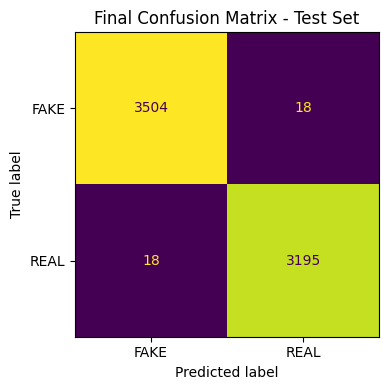

In [36]:
# confusion matrix on test
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['FAKE', 'REAL']).plot(ax=ax, colorbar=False)
ax.set_title('Final Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()


results:
- accuracy:  0.9947
- precision: 0.9944
- recall:    0.9944
- f1:        0.9944

confusion matrix:
- correctly predicted FAKE: 3504 out of 3522
- correctly predicted REAL: 3195 out of 3213
- wrong predictions: only 36 out of 6735

the model performs very well on unseen data
close to the validation scores which means no overfitting